# Comparison of the Gastronomy  and Illegal Deposited Waste and Littering in Zürich

Author: Tim Berger  
Date: 22.5.2026
<br>
<br>

### Introduction
The Zürich wie neu website allows the residents of Zürich to report damage and defects of the infrastructure of the city.  
Reports are sorted in different categories, such as waste or graffiti.   
Illegal deposited waste and littering in the "Abfall/ Sammelstelle" category is reported most frequently (see category frequency analysis).  
It is highly likely that there is more littering in areas where people go out; this could explain the differences between the heatmap and the waste reports per resident.  
This analysis therefore investigates the correlation between the density of gastronomic locations and the rate of litter reports per resident. 
<br>
<br>

### Research Question: 
is there a correlation between the density of gastronomic locations and the rate of litter reports per resident?
<br>
<br>

### Requirements and Sources
See README file

<br>
<br>

import packages


In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from scipy import stats
import datetime as dt

import notebook_utils

### **Load Data from the Website of the City of Zürich**

In [2]:
url_zwn = "https://www.ogd.stadt-zuerich.ch/wfs/geoportal/Zueri_wie_neu?service=WFS&version=1.1.0&request=GetFeature&outputFormat=GeoJSON&typename=zwn_meldungen_p"
url_neighbourhoods = "https://www.ogd.stadt-zuerich.ch/wfs/geoportal/Statistische_Quartiere?service=WFS&version=1.1.0&request=GetFeature&outputFormat=GeoJSON&typename=adm_statistische_quartiere_v"
url_population = 'https://data.stadt-zuerich.ch/api/3/action/datastore_search?resource_id=9f9e2f24-96a7-4542-843c-52d44a904110&limit=10000'
url_gastronomy = 'https://www.ogd.stadt-zuerich.ch/wfs/geoportal/Gastwirtschaftsbetriebe?service=WFS&version=1.1.0&request=GetFeature&outputFormat=GeoJSON&typename=gastwirtschaftsbetriebe'

zwn_gdf_raw = notebook_utils.import_geografic_data(url_zwn)
neighbourhoods_gdf_raw = notebook_utils.import_geografic_data(url_neighbourhoods)
population_df_raw = notebook_utils.import_data(url_population)
gastronomy_gdf_raw = notebook_utils.import_geografic_data(url_gastronomy)

data loaded successfully
data loaded successfully
data loaded successfully
data loaded successfully


### **Clean the Data**

- clean gastronomy data

In [3]:

# filter the gastronomy data for the required columns
gastronomy_gdf = gastronomy_gdf_raw[["betriebsname", "quarlang"]].copy()

# create a series with the neighbourhoods as index and the number of gastronomy locations as values
neighbourhood_with_gastro = gastronomy_gdf["quarlang"].value_counts()
neighbourhood_with_gastro = neighbourhood_with_gastro.rename("gastronomy")

# have a look if everything worked and if there are NA values
neighbourhood_with_gastro.info()


<class 'pandas.Series'>
Index: 34 entries, Langstrasse to Leimbach
Series name: gastronomy
Non-Null Count  Dtype
--------------  -----
34 non-null     int64
dtypes: int64(1)
memory usage: 853.0 bytes


- clean 'Züri wie neu' data

In [4]:
# Sort the züri wie neu data for waste 
zwn_waste_gdf = zwn_gdf_raw[zwn_gdf_raw["service_name"]=="Abfall/Sammelstelle"].copy()

# filter for required columns
zwn_waste_gdf = zwn_waste_gdf[["service_request_id", "title", "geometry"]]

# have a look if everything worked and if there are NA values
zwn_waste_gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 27670 entries, 4 to 73342
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   service_request_id  27670 non-null  str     
 1   title               27670 non-null  str     
 2   geometry            27670 non-null  geometry
dtypes: geometry(1), str(2)
memory usage: 1.3 MB


- clean neighbourhood data

In [5]:
#clean neighbourhoods file

neighbourhoods_gdf = neighbourhoods_gdf_raw[["qname", "qnr", "geometry"]].copy()

# have a look if everything worked and if there are NA values
neighbourhoods_gdf.info()


<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   qname     34 non-null     str     
 1   qnr       34 non-null     int32   
 2   geometry  34 non-null     geometry
dtypes: geometry(1), int32(1), str(1)
memory usage: 1.1 KB


- clean population data

In [6]:
# filter population for the newest year

# display the current year
current_year = int(dt.date.today().year)

# filter dataframe for the newest year
population_df = population_df_raw[population_df_raw["StichtagDatJahr"] == str(current_year-1)].copy()

# clean the population data
#drop the columns not needed
population_df= population_df.drop(columns=["StichtagDatJahr", "QuarSort", "_id"])

# convert numbers to integer
population_df["AnzBestWir"] = population_df["AnzBestWir"].astype(int)

# rename the columns
population_df = population_df.rename(columns={"AnzBestWir": "population", "QuarLang": "qname"})

# have a look if everything worked and if there are NA values
population_df.info()

<class 'pandas.DataFrame'>
Index: 34 entries, 0 to 2729
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   qname       34 non-null     str  
 1   population  34 non-null     int64
dtypes: int64(1), str(1)
memory usage: 1.1 KB


### **Join and Merge Data**

- merge waste points and neighbourhoods

In [7]:

#join the trash points to the neighbourhoods

waste_with_neighbourhoods_df = gpd.sjoin(zwn_waste_gdf, 
                                          neighbourhoods_gdf,
                                          how="inner",
                                          predicate="within")


#count the number of waste per neighbourhood and safe it as a dataframe waste_gastro_df
waste_gastro_df = waste_with_neighbourhoods_df[["qname"]].value_counts().to_frame()

# rename the column
waste_gastro_df = waste_gastro_df.rename(columns={"count":"count_waste"})


- merge the gastronomy to the neighbourhoods and waste

In [8]:
# merge the gastronomy to waste_gastro_df
waste_gastro_df = pd.merge(left=waste_gastro_df, 
                                        right=neighbourhood_with_gastro,
                                        left_on="qname",
                                        right_index=True
                                        )

- add population number to the dataframe

In [9]:
# merge the population to the waste_gastro_df

waste_gastro_df = pd.merge(left=waste_gastro_df, 
                                        right=population_df,
                                        left_index=True,
                                        right_on="qname")

- add the geometry of the neighbourhoods to the dataframe

In [10]:
# merge waste_gastro_df with the neighbourhood geometries
waste_gastro_gdf = pd.merge(left=neighbourhoods_gdf, 
                                        right=waste_gastro_df,
                                        left_on="qname",
                                        right_on="qname")

# create a new column with the gastronomy location density 
waste_gastro_gdf["gastronomy_density"] = 10000* waste_gastro_gdf["gastronomy"]/waste_gastro_gdf.geometry.area

# create a new column with the waste rate per population
waste_gastro_gdf["waste_rate"] = waste_gastro_gdf["count_waste"]/waste_gastro_gdf["population"]

# sort the values by the gastronomy density
waste_gastro_gdf = waste_gastro_gdf.sort_values(by= "gastronomy_density", ascending=True)

waste_gastro_gdf = waste_gastro_gdf.set_index("qname")

# have a look if everything worked 
waste_gastro_df.head(5)

,count_waste,gastronomy,qname,population
917,3883,362,Langstrasse,11978
747,3167,185,Sihlfeld,21478
1002,1646,75,Hard,12817
2107,1416,205,Altstetten,36874
595,1294,128,Alt-Wiedikon,18904


### **Plot Data**

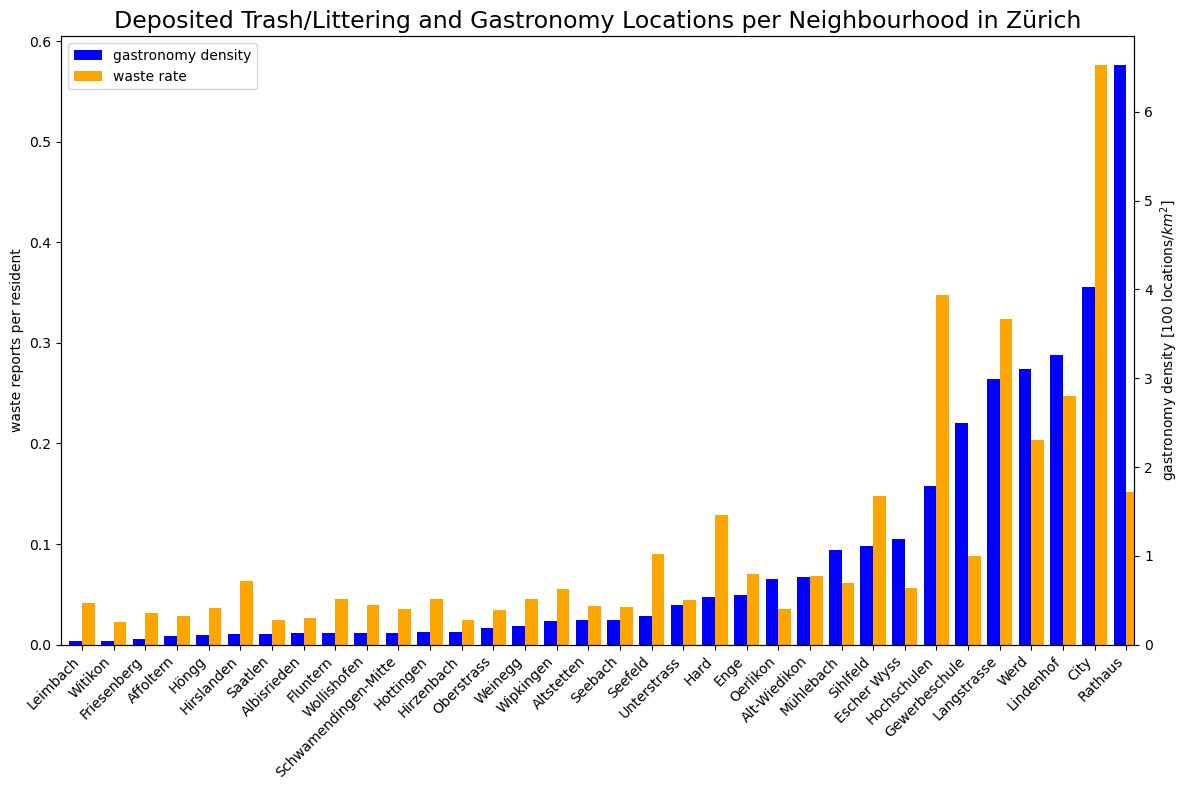

In [18]:
fig, ax1 = plt.subplots(figsize= (12,8))

# create a second ax that shares the x axis with ax1
ax2 = ax1.twinx()

# plot the waste per population
waste_gastro_gdf["waste_rate"].plot(kind="bar", 
                                        ax=ax1, 
                                        width= 0.4, 
                                        position=0, 
                                        color= "orange",
                                        ylabel="waste reports per resident",
                                        xlabel="")

# set a title
ax1.set_title("Deposited Trash/Littering and Gastronomy Locations per Neighbourhood in Zürich", size=17)

waste_gastro_gdf["gastronomy_density"].plot(kind="bar", ax=ax2, width= 0.4, position=1, color= "blue",
                         ylabel="gastronomy density [100 locations/$km^2$]")

#add a legend
handles_gastro, labels_gastro = ax2.get_legend_handles_labels()
handles_waste, labels_waste = ax1.get_legend_handles_labels()
ax2.legend(handles_gastro + handles_waste, ["gastronomy density", "waste rate"], loc="upper left")


plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, horizontalalignment="right")
plt.tight_layout()

# save figure in the figures folder
fig.savefig("../figures/gastronomy_waste_bar.png", dpi=300, bbox_inches="tight")

plt.show()

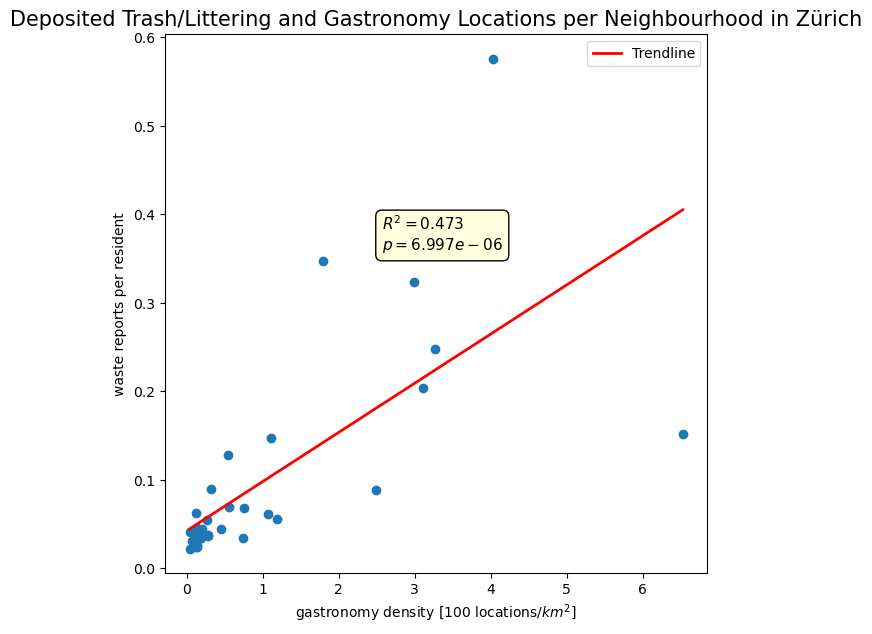

In [19]:
fig, ax3 = plt.subplots(figsize= (7,7))

# safe the waste rate and gastronomy density under the x and y variables
y= waste_gastro_gdf["waste_rate"]
x= waste_gastro_gdf["gastronomy_density"]

# create a scatterplot 
ax3.scatter(x,y)
ax3.set_ylabel("waste reports per resident")
ax3.set_xlabel("gastronomy density [100 locations/$km^2$]")
ax3.set_title("Deposited Trash/Littering and Gastronomy Locations per Neighbourhood in Zürich", size=15)

# apply a linear regression
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

# calculate the r squarred
r_squared = r_value**2

# plot the fitted line
y_line = slope * x + intercept
ax3.plot(x, y_line, color='red', linewidth=2, label='Trendline')

# add the r squared and p value
ax3.annotate(
    f'$R^2 = {r_squared:.3f}$\n$p = {p_value:.3e}$',
    xy=(0.4, 0.6), xycoords='axes fraction', fontsize=11,
    bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', edgecolor='black'))

# save figure in the figures folder
fig.savefig("../figures/reports_categories_scatter.png", dpi=300, bbox_inches="tight")

plt.legend()
plt.show()

### **Results**

The bar and scatterplot show a correlation between the number of gastronomy location per area and the waste reports per resident. Still, it is really scattered and there are also some outliers, like the Rathaus neighbourhood. This has a really high gastronomy location density, but at the same time an only medium amount of waste per resident. An explanation for this could be the dense and historic style of the area and the high number of tourists, leading to a high gastronomy density. However, with an R2 of 0.47 also not much of the variation of the waste reports per resident is explained by the gastronomy density.